# mechanism_viewer real-world examples

## Contraceptive Method Choice dataset

For the testing of `mechanism_viewer` practicability, a real-world dataset was selected. In particular, the Contraceptive Method Choice (CMC) dataset, is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey. Each row represents a married woman who was either not pregnant or did not know whether she was pregnant at the time of the interview. The original prediction task was to classify the current contraceptive method choice into `1` (No-use), `2` (Long-term method), and `3` (Short-term method).

> Note: The dataset has no missing values. Therefore, this notebook creates a controlled missingness copy of the data. The injected missingness is only for testing and demonstration, and it should not be reported as the real missingness of the dataset.

For this notebook, the goal is different: the dataset will be used as a way to evaluate whether `mechanism_viewer` can help identify missing patterns as `MCAR`,`MAR`, or `MNAR`.

>Note: `mechanism_viewer` is an exploratory package, and interpretations of its results should always be made with caution.

### 1. Load the dataset

The raw file does not contain a header row, so the column names are added manually from the `.names` file.

In [1]:
import pandas as pd

columns = ["wife_age", "wife_education", "husband_education",
           "num_children", "wife_religion", "wife_working", "husband_occupation",
           "standard_living_index", "media_exposure", "contraceptive_method"]

df = pd.read_csv("../sample_data/contraceptive/cmc.data", header=None, names=columns)

display(df.head())

,wife_age,wife_education,husband_education,num_children,wife_religion,wife_working,husband_occupation,standard_living_index,media_exposure,contraceptive_method
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


### 2. Explore the dataset

The original dataset is complete, so there will be no missing values in the 10 columns, as confirmed below.

In [2]:
print("Dataset shape:", df.shape)
print("Total of missing values in the dataset:", int(df.isna().sum().sum()))

Dataset shape: (1473, 10)
Total of missing values in the dataset: 0


Furthermore, as the data is already in numeric format, no extra encoding is needed for the package tools. Nevertheless, not all variables are continuous,  several are ordinal, binary, or categorical codes. Thus, correlations involving these variables should be interpreted carefully as coded-category associations.

The next dictionary summarises the contents of `.names` file.

In [3]:
data_dictionary = pd.DataFrame({
    "column": columns,
    "meaning": ["Wife's age",
                "Wife's education: 1=low, 4=high",
                "Husband's education: 1=low, 4=high",
                "Number of children ever born",
                "Wife's religion: 0=Non-Islam, 1=Islam",
                "Wife now working: 0=Yes, 1=No",
                "Husband's occupation: categories 1, 2, 3, 4",
                "Standard-of-living index: 1=low, 4=high",
                "Media exposure: 0=Good, 1=Not good",
                "Contraceptive method: 1=No-use, 2=Long-term, 3=Short-term"
            ],
    "type": ["discrete",
             "ordinal categorical",
             "ordinal categorical",
             "discrete",
             "binary",
             "binary",
             "discrete categorical",
             "ordinal categorical",
             "binary",
             "target categorical"
             ]})

display(data_dictionary)

,column,meaning,type
0,wife_age,Wife's age,discrete
1,wife_education,"Wife's education: 1=low, 4=high",ordinal categorical
2,husband_education,"Husband's education: 1=low, 4=high",ordinal categorical
3,num_children,Number of children ever born,discrete
4,wife_religion,"Wife's religion: 0=Non-Islam, 1=Islam",binary
5,wife_working,"Wife now working: 0=Yes, 1=No",binary
6,husband_occupation,"Husband's occupation: categories 1, 2, 3, 4",discrete categorical
7,standard_living_index,"Standard-of-living index: 1=low, 4=high",ordinal categorical
8,media_exposure,"Media exposure: 0=Good, 1=Not good",binary
9,contraceptive_method,"Contraceptive method: 1=No-use, 2=Long-term, 3...",target categorical


Although it is more common to encode 1 as the positive category and 0 as its absence, this dataset uses the opposite convention. For example, the feature determining if wife is currently working is coded as 0 = Yes and 1 = No. The only exception is ``wife_religion``, where 0 = Non‑Islam and 1 = Islam. These small insights should be taken into consideration on the future analsisys of the dataset.

Anyway, the code below gives a quick view of the observed distributions, when no missingness is applied.

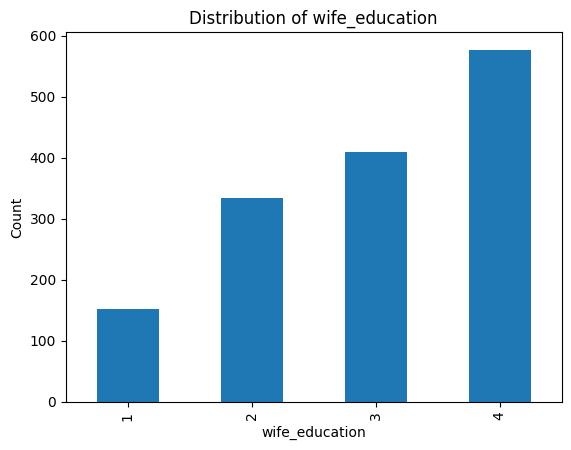

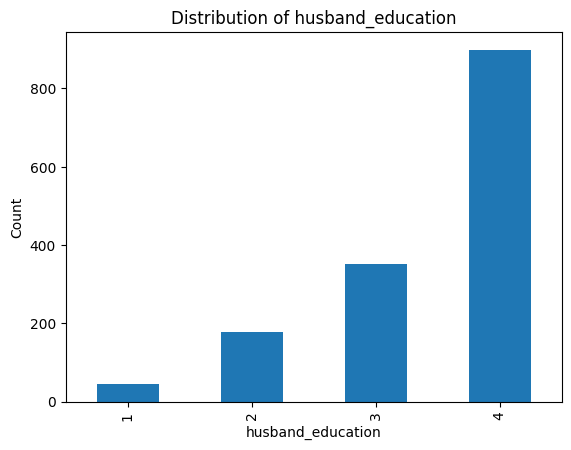

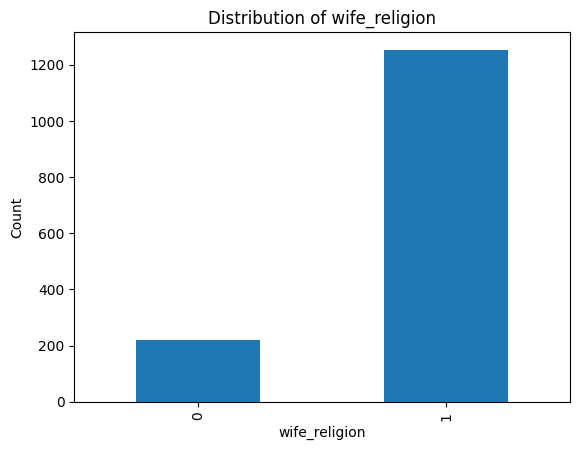

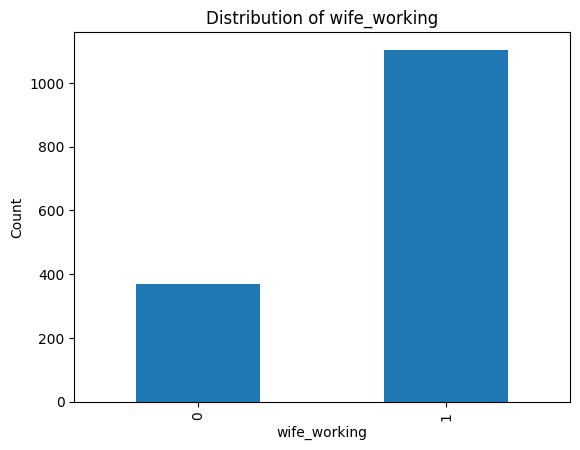

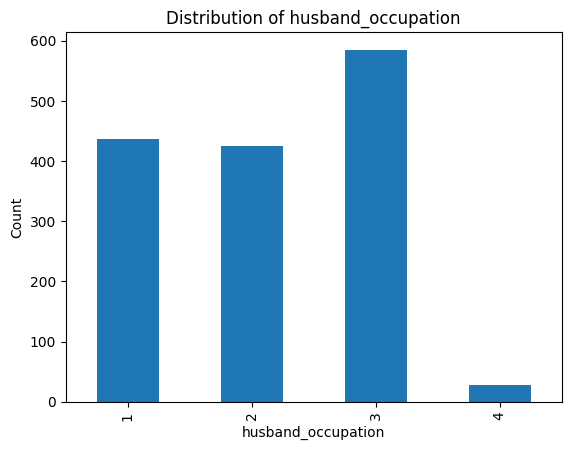

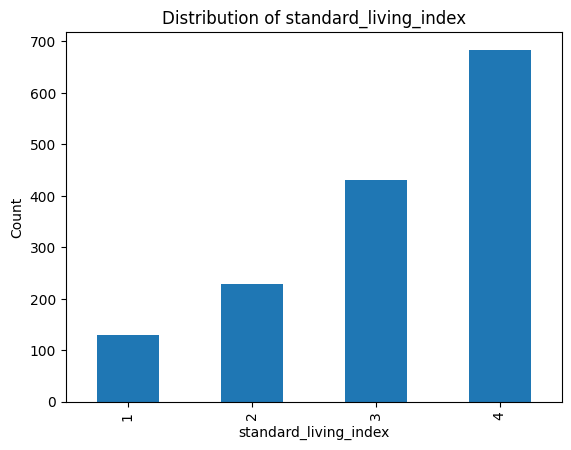

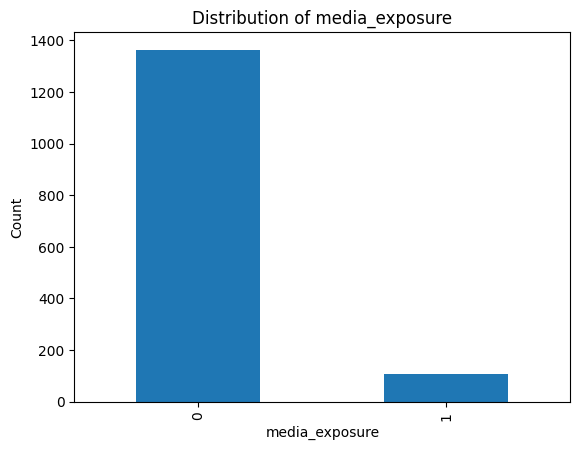

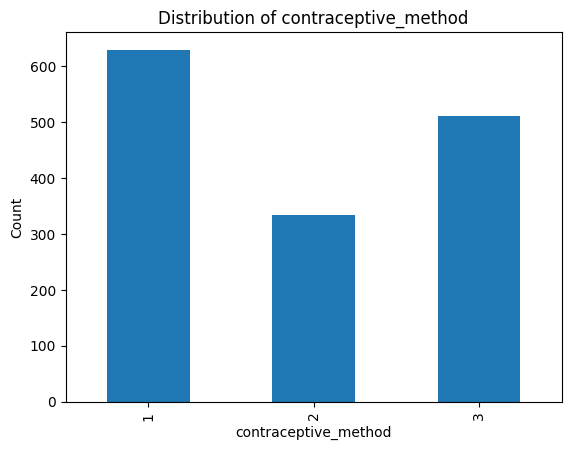

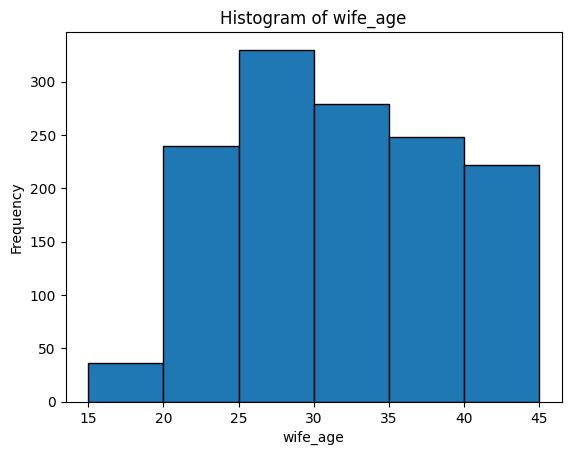

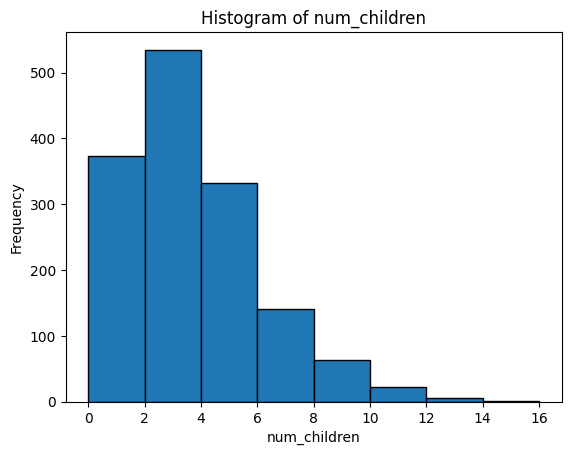

In [4]:
import numpy as np
import matplotlib.pyplot as plt

columns = ["wife_education", "husband_education", "wife_religion", "wife_working", "husband_occupation", "standard_living_index", "media_exposure", "contraceptive_method"]

for column in columns:
    df[column].value_counts().sort_index().plot(kind="bar", title=f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

for column, bin_num in [("wife_age", 5), ("num_children", 2)]:
    bins = np.arange(bin_num * (df[column].min() // bin_num), bin_num * (df[column].max() // bin_num + 1), bin_num)
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### 3. Create a controlled missingness copy

To test the package in a realistic setting, a copy named `missing_df` was create that has different missingness mechanisms applied:

- `wife_working`: applied with **MCAR** with random missing rate of 8%.
- `media_exposure`: applied with **MCAR** with random missing rate of 10%.
- `standard_living_index`: applied with **MAR**. More likely to be missing for rows with higher category code on the following observed columns:  `wife_education`, `husband_education`, and `contraceptive_method`.
- `husband_occupation`: applied with **MAR**. More likely to be missing for rows with lower `wife_education` and `husband_education`.
- `num_children`: applied with **MNAR**. More likely to be missing when its own value is high.

>Note: Columns with MCAR missingness use different random seeds so that the missing values do not occur in the same rows.

This gives a mixed missingness scenario where some patterns are easy to identify and others are more ambiguous.

In [6]:
from mechanism_viewer import apply_mcar, apply_mar, apply_mnar, DEFAULT_RANDOM_STATE

missing_df = df.copy()

# MCAR
missing_df["wife_working"] = apply_mcar(missing_df["wife_working"], missing_rate=0.08, random_state=DEFAULT_RANDOM_STATE)
missing_df["media_exposure"] = apply_mcar(missing_df["media_exposure"], missing_rate=0.10, random_state=DEFAULT_RANDOM_STATE+1)

# MAR
missing_df["standard_living_index"] = apply_mar(missing_df["standard_living_index"],
                                                observable_df=missing_df[["wife_education", "husband_education", "contraceptive_method"]],
                                                missing_rate=0.18, missingness_ascending=True)
missing_df["husband_occupation"] = apply_mar(missing_df["husband_occupation"],
                                            observable_df=missing_df[["wife_education", "husband_education"]],
                                            missing_rate=0.14, missingness_ascending=False)

# MNAR
missing_df["num_children"] = apply_mnar(missing_df["num_children"], missing_rate=0.16, missingness_ascending=True)

### 4. Missing-rate plot after applying missing mechanisms

To confirm if the missingness mechanisms were applied, `plot_missing_rate()` can be used:

C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\viewer_simple.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_missing_rate.tight_layout()


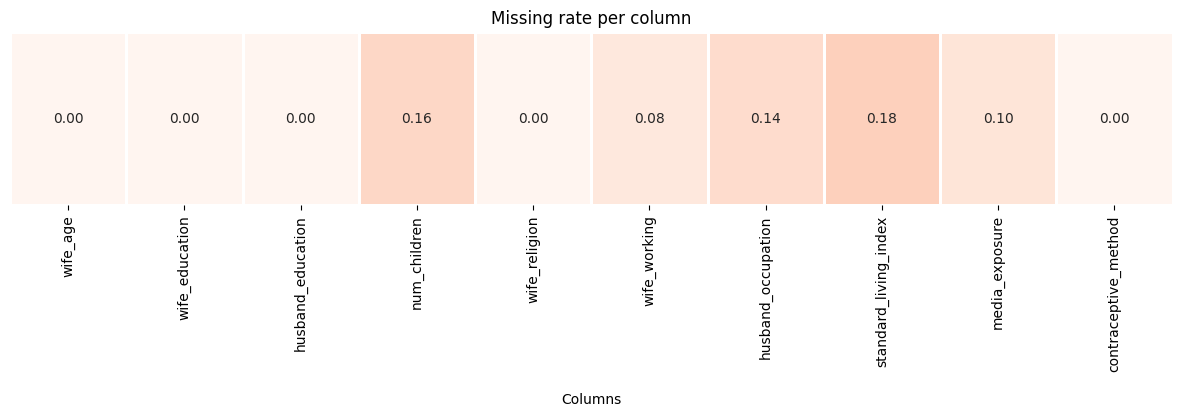

In [8]:
import mechanism_viewer as mv

_, _ = mv.plot_missing_rate(missing_df, display_plot=True)

This confirms that only the selected columns contain missing values. Thus, a missingness analysis can be done to the altered dataset.

> Note: The following sections will provide a missingness analysis, under the assumption that no prior information about the applied patterns is known.

### 5. Rows with similar missing-value patterns

This plot is similar to an UpSet plot and it shows which columns tend to be missing together in the same rows.

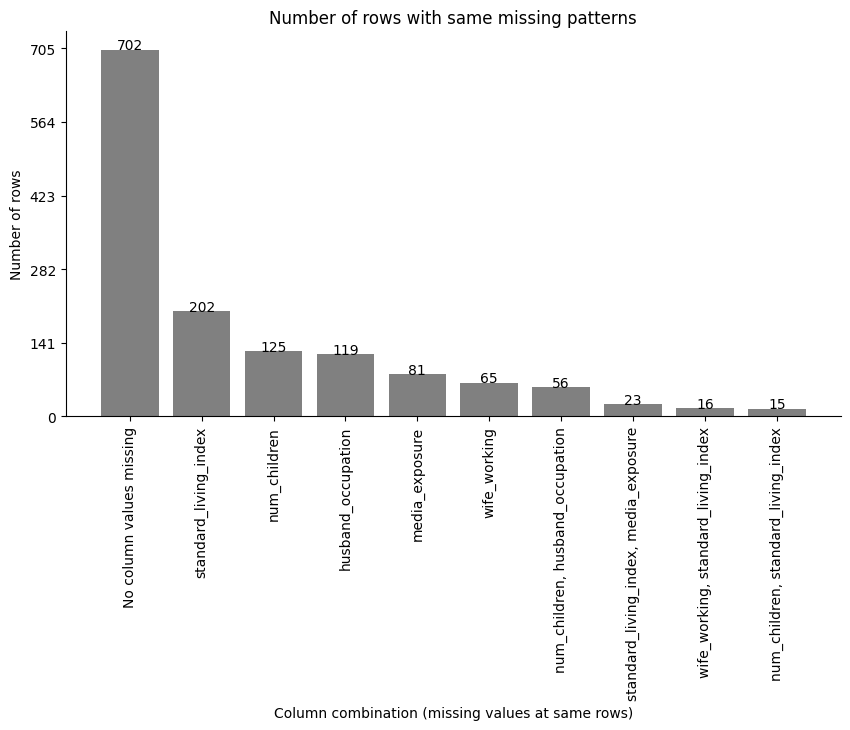

In [9]:
_, _ = mv.upset_missing_rows(missing_df, min_rows_display=15 ,display_plot=True)

In this dataset, the previously identified missing columns are now visible, each showing its own pattern of missing rows. While some rows naturally contain overlapping missing values in various columns, no meaningful groups of variables have appeared, as the overall amount of missingness is small.

### 6. Missingness correlation heatmaps

To examine how the patterns relate to one another, multiple heatmaps can be used. The first plot will display the missingness correlation between all columns with missing values.

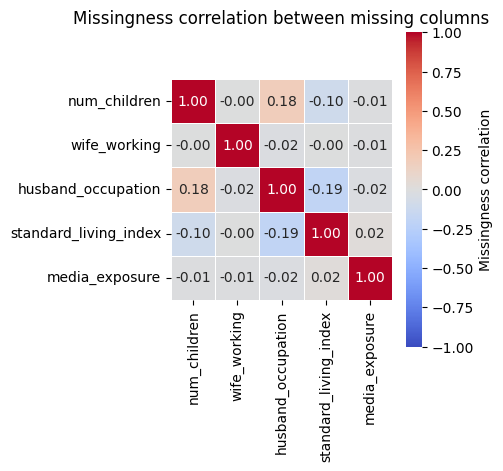

In [ ]:
from mechanism_viewer import missingness_misscol_corr, complete_and_misscol_corr

_, _= missingness_misscol_corr(missing_df, display_plot=True)

Overall, there is no missingness relation between the missing columns, so the missingness patterns are mostly independent from each other. Despite that, `num_children` has a small signal with ``husband_occupation``, which may indicate that rows missing ``num_children`` are slightly more likely to also miss ``husband_occupation``. However, there is not enough shared missingness to indicate a strong common mechanism. 

There is also a similar case with `husband_occupation` and `standartd_living_index`, where it seems that while one has missing values, the other column is slightly more likely to have a non-missing value. Of course, more plotting needs to be done to confirm the underlying patterns and their respective dependencies.

The next plot compares the missingness from missing columns with the values of complete columns. It is useful for detecting MAR patterns, because MAR missingness should be explainable by observed variables.

>Note: Because many variables of this dataset are numeric codes for categories, these correlations should be treated as exploratory insights.

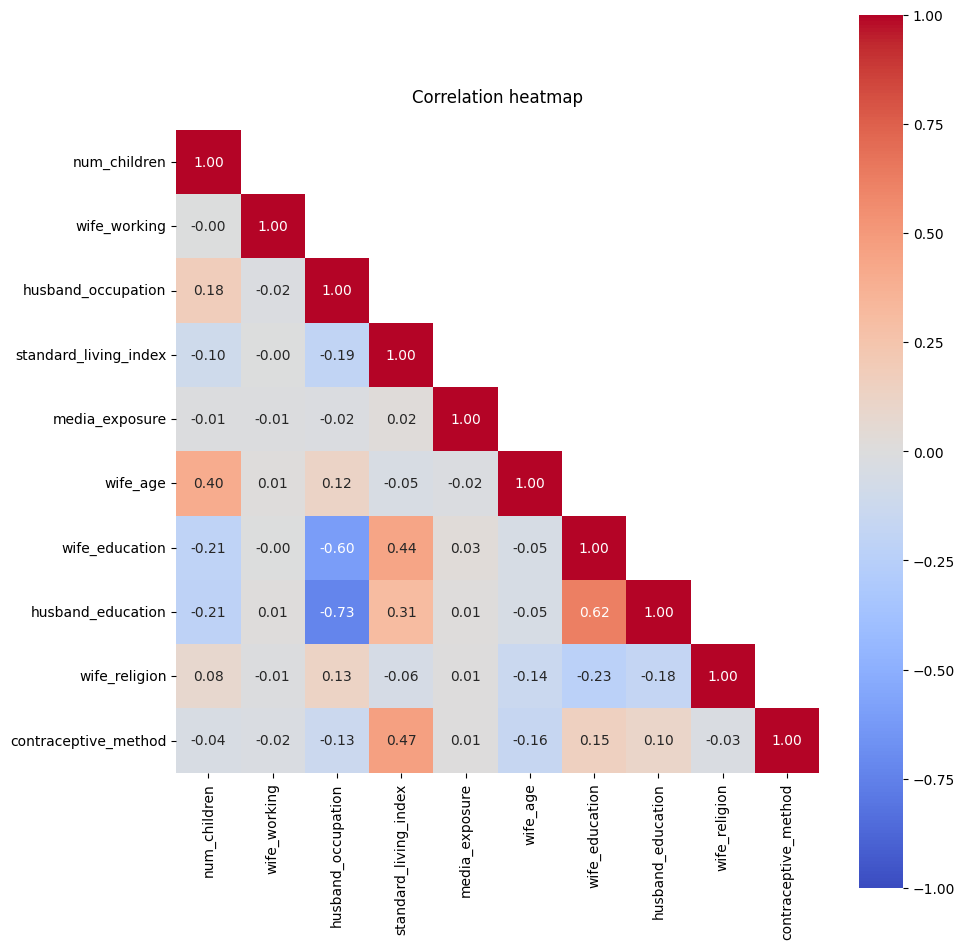

In [ ]:
_, _ = mv.complete_and_misscol_corr(missing_df, display_plot=True)

Some interesting behaviours come to light on this heatmap. For example, `num_children` seems to have its missingness associated with `wife_age` (0.40), `wife_education` (-0.21), `husband_education` (-0.21) and even `husband_occupation` (0.18). This may be due to `wife_education` having strong correlation with `husband_education` (0.62), and light correlation with `wife_religion` (-0.23) and ``contraceptive_method`` (0.15). In turn, `husband_education` has also weak association with `wife_religion` and `contraceptive_method`.

There are 2 complete columns that present weak to no association with any other column. Those are `wife_age` and `wife_religion`. In addition, there are 2 missing features that have no associations, which are `wife_working` and `media_exposure`. Most likely, these last 2 columns may have a MCAR missing-data mechanism applied.

Another case to look into is ``standartd_living_index``, having correlation with `contraceptive_method` (0.47), `wife_education` (0.44), and `husband_education` (0.31).

Finally, `husband_occupation` has very strong association with `wife_education` (-0.60), and `husband_education` (-0.73). The feature also has weak correlation with ``standartd_living_index``, probably because ``standartd_living_index`` has also high correlation with the previous complete features.

Now, to make sure the obtained correlations reveal multiple missigness dependencies, instead of being pure value relationships, a simple correlation heatmap can be plotted. This heatmap only displays the value correlations between every column.

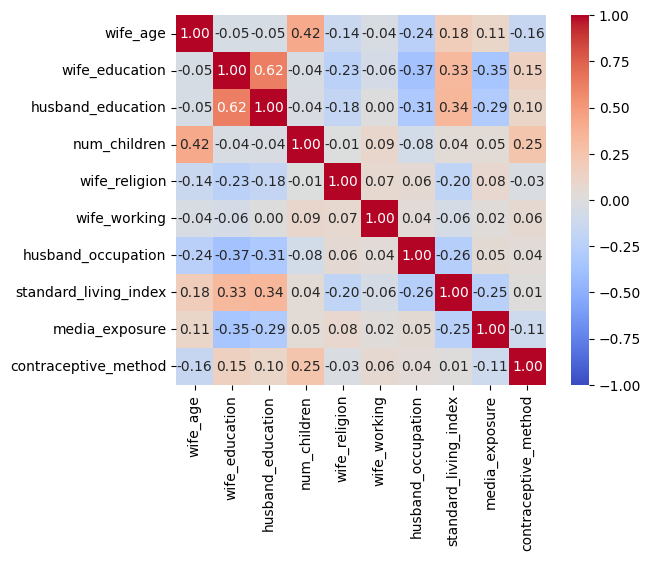

In [ ]:
import seaborn as sns
import numpy as np

correlation_matrix = missing_df.corr()

_ = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)

From this heatmap, the highest value correlation is between ``husband_education`` with `wife_education`, and `wife_age` with `num_children`. Both ``husband_education`` and `wife_education` are complete columns, thus this association only entails that whenever a missing column depends on either of these features, it will also present high association with the other complete column. The association between `wife_age` and `num_children` is more interesting, as `num_children` is one of the missing features, and `wife_age` was a potential missing dependency for the missing feature on the other heatmap. With the result of this plot, it is confirmed that `wife_age` correlation with `num_children` maintained when the focus is towards the missigness of `num_children`, compared to the correlation provided between the two columns values.

Actually, this heatmap provides a value correlation between `num_children` and `contraceptive_method` of 0.25 that was absent on the missigness correlation plot (-0.04). In addition, `wife_education`, `husband_education` and `husband_occupation` correlation with `num_children` increase on the missigness correlation plot, compared to their value correlation. If ``num_children`` had a MCAR pattern, then it was expected for its missingness to have very weak or random associations with all observed features. But in this case, the missingness seems to shift toward education/occupation related variables. It is possible for ``num_children`` to have a weak MAR signal, since this correlation mismatch suggests that the missingness process may be different from the process of generating values. However, further tests are necessary to confirm this pattern, especially due to the `wife_age` maintaining its correlation while other observed columns have theirs shifted. 

Apart from this, `wife_working` display very weak associations with all observed features, both at the missingness heatmap and at the value correlation plot. Thus, a MCAR pattern is the most probable for this feature. For the case of `media_exposure`, there is some value correlation with `husband_education` and `wife_education`, but due to the absence of missingness correlation, it is also likely that the variable has MCAR mechanism.

On the other hand, `husband_occupation` has also value correlation with ``husband_education`` (-0.31), `wife_education` (-0.37), ``standartd_living_index`` (-0.26), and `wife_age` (-0.24). By analysing deeper, the correlations of ``husband_education`` and `wife_education` are higher on the missingness plot, while ``standartd_living_index`` and `wife_age` are lower. This suggests that `husband_occupation` may have a more convincing MAR mechanism than `num_children`. It is likely that the main features that affect the missingness are `husband_education` and `wife_education`. 

Furthermore, ``standartd_living_index`` maintains its correlation with `husband_education`(0.34), while `wife_education` has slight higher correlation at the missigness plot (0.44) compared to this heatmap (0.33). The most shocking part is that `contraceptive_method` does not reflect any value correlation with `standartd_living_index` (0.01), although in the missingness plot it was the highest correlation (0.47). As a consequence, it is likely that `standartd_living_index` has a MAR missing-data mechanism, mainly affected by `contraceptive_method`. Additionally, `wife_age`, `wife_religion` and `husband_occupation` have lower correlation values with `standartd_living_index` at the missigness plot. 

It is intriguing that `husband_occupation` and `standartd_living_index` have lower missingness correlation, although both have a low `wife_age` missingness correlation. However, a more informative comparison comes from their correlations with ``wife_education``. For both variables, the absolute correlation with ``wife_education`` increases in the missingness plot, but in opposite directions: ``husband_occupation`` shifts from –0.37 to –0.60, while ``standartd_living_index`` increases from 0.33 to 0.44. Thus it is possible that the missingness of `husband_occupation` and `standartd_living_index` are not dependent on `wife_age`, but are dependent on `wife_education` but in oposite direction. In other words, while `standartd_living_index` missingness increases with higher values of `wife_education`, the missingness of `husband_occupation` is affected by the lower values of `wife_education`.

### 7. MAR check using model accuracy

The function `test_mar_from_model_accuracy()` trains models to predict whether a column is missing using complete columns. If the missingness can be predicted much better than a baseline, the missingness is likely explainable by observed variables and therefore likely MAR.

In [ ]:
from mechanism_viewer import test_mar_from_model_accuracy

missing_cols = ["num_children", "wife_working", "husband_occupation", "standard_living_index", "media_exposure"]
for missing_col in missing_cols:
    test_mar_from_model_accuracy(missing_df, missing_col, threshold=5.0)
    print()

Random Forest Model Accuracy: 0.8213
Logistic Regression Model Accuracy: 0.8326
The target column num_children with missing rate of 0.1595 gives an Accuracy Baseline Difference of -1.35.
Since the obtained Accuracy Baseline Difference is -1.35, and the given threshold is 5.0, thus, it is likely that the underlying mechanism of the missing column is MCAR/MNAR.

Random Forest Model Accuracy: 0.8801
Logistic Regression Model Accuracy: 0.9208
The target column wife_working with missing rate of 0.0794 gives an Accuracy Baseline Difference of -2.01.
Since the obtained Accuracy Baseline Difference is -2.01, and the given threshold is 5.0, thus, it is likely that the underlying mechanism of the missing column is MCAR/MNAR.

Random Forest Model Accuracy: 0.9729
Logistic Regression Model Accuracy: 0.9774
The target column husband_occupation with missing rate of 0.1399 gives an Accuracy Baseline Difference of 11.5.
Since the obtained Accuracy Baseline Difference is 11.5, and the given threshold i

Some insights are reinforced by this test. For instance, both ``standard_living_index`` and ``husband_occupation`` show a strong positive Accuracy Baseline Difference (ABD), a pattern typically associated with MAR variables. If these features were truly MCAR, their ABD values would be expected to remain close to zero or even negative. That is exactly what happens with the other missing columns (`num_children`, `wife_working` and `media_exposure`), whose ABD values are between –1.35 and –2.01, which is consistent with a MCAR/MNAR behavior.

### 8. View dependencies caused by observable columns

To verify whether the variables follow the hypothesized missing‑data mechanisms, the next analysis examines whether the observed predictors identified in earlier plots actually change the missingness rate of the incomplete features. For that, the function `missing_rate_matrix()` can be used to detect substantial variations in missing rate throughtout the observable variables.

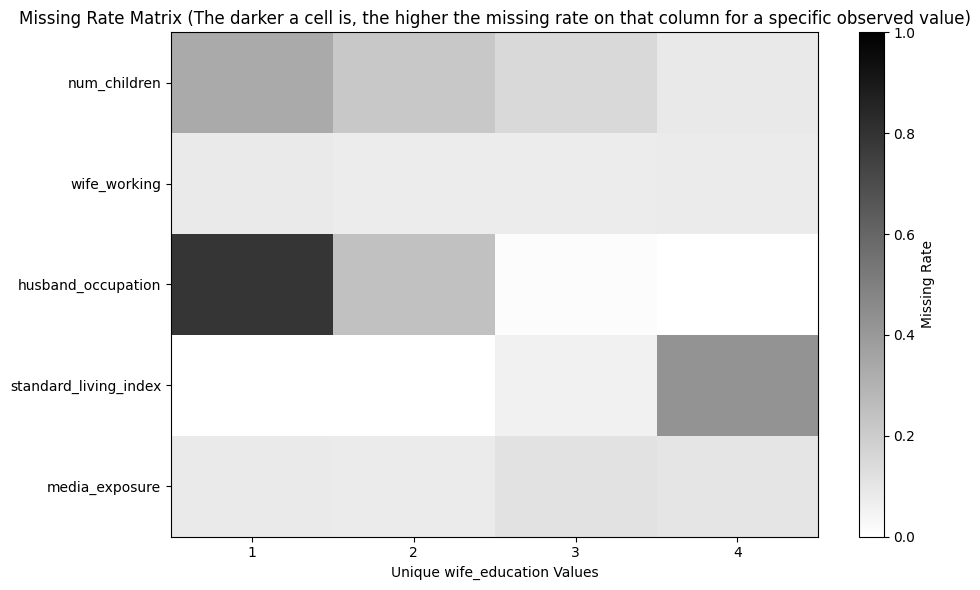

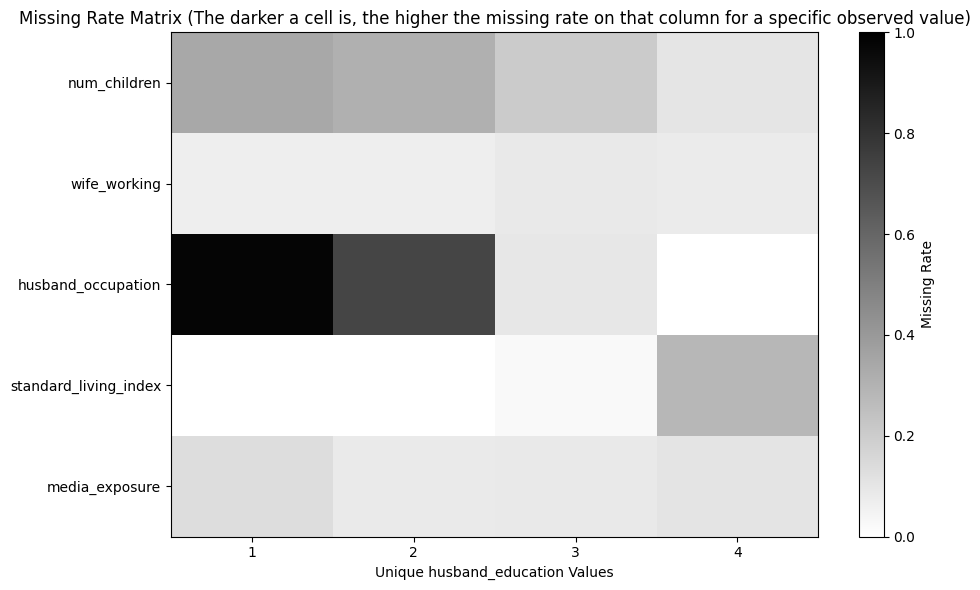

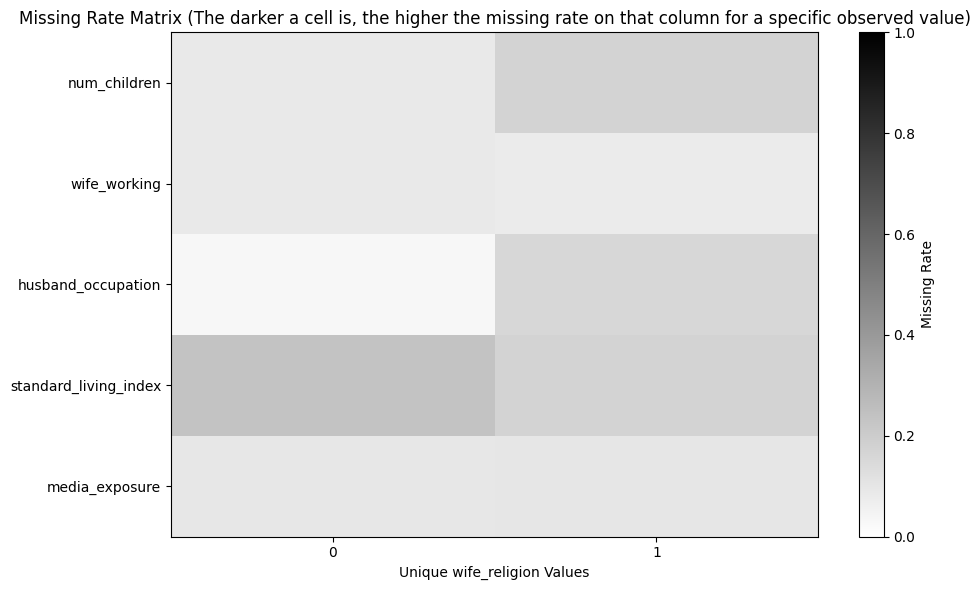

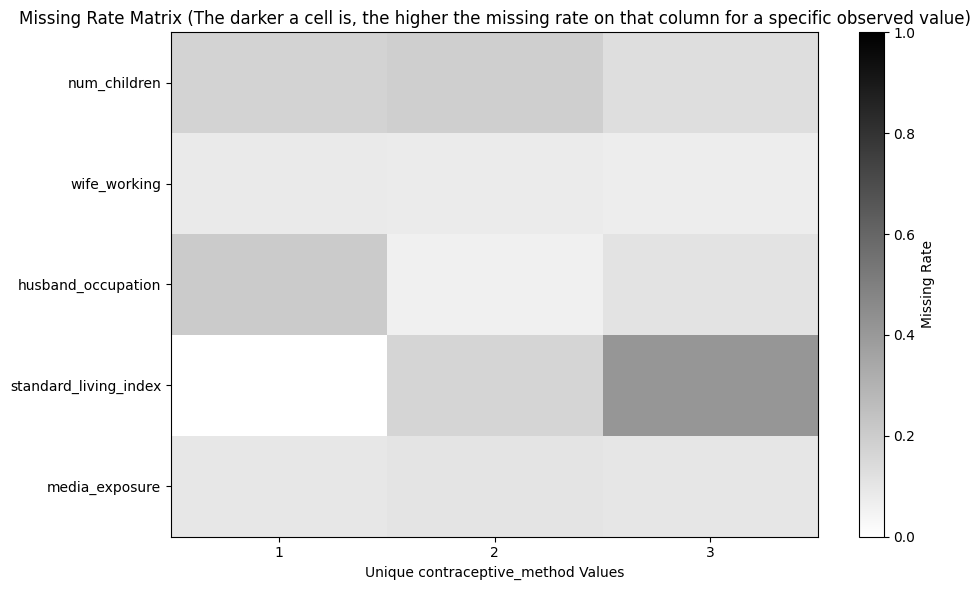

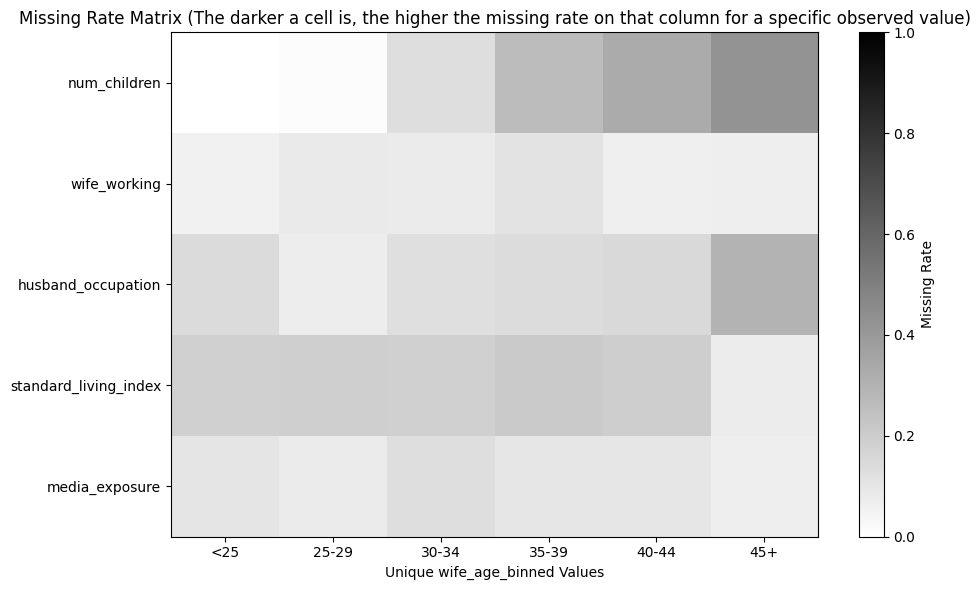

In [ ]:
from mechanism_viewer import missing_rate_matrix

df_binned = missing_df.copy()

df_binned["wife_age_binned"] = pd.cut(df_binned["wife_age"], bins=[0, 25, 30, 35, 40, 45, np.inf],
                                        labels=["<25", "25-29", "30-34", "35-39", "40-44", "45+"],
                                        right=False, include_lowest=True)
for column in df_binned.columns:
    if column not in missing_cols:
        if column not in ["wife_age"]:
            _, _ = missing_rate_matrix(df_binned[missing_cols + [column]], column_name=column, display_plot=True)


These plots provide a clearer view of the MAR patterns for each column than the correlation heatmaps.

For ``num_children``, missingness increases with ``wife_age``. Since the observed values of ``num_children`` are also correlated with ``wife_age``, the missingness pattern appears to follow the same structure as the variable itself. This suggests that the missingness is not random. However, it is difficult to separate whether the missingness is directly driven by the observed variable ``wife_age``(MAR), or indirectly by the underlying values of ``num_children`` (MNAR), because these two variables are naturally related.

`husband_occupation` exhibits the strongest relationship between missingness and observed features. Missing rates are highest in the lowest categories of `husband_education` and `wife_education` and decline as education increases. This pattern indicates MAR, where the absence of `husband_occupation` data is linked to education levels. Given that the previous test also suggested MAR, it is likely that missingness in this feature depends on these two education variables.

In contrast, `standard_living_index` does not follow the low education trend observed for `husband_occupation`. Its missing rate actually increases at higher levels of `husband_education` and `wife_education`. Importantly, missingness appears to vary with `contraceptive_method`, which is not observed for other missing columns. This indicates that `standard_living_index` is not completely random, and while the pattern is less straightforward than for `husband_occupation`, the previous test's MAR result makes a MAR mechanism plausible.

`wife_working` displays consistently low and stable missing rates across observed groups, suggesting little or no dependency on the tested variables. This behavior aligns more closely with MCAR than the other features, supporting the earlier hypothesis.

Finally, `media_exposure` shows only minor variations across observed groups. There is no strong evidence from these plots that its missingness is substantially influenced by the tested variables.

### 9. Detailed check of `standard_living_index`
The next function will focus on examining the rows with missing values in the ``standard_living_index`` column, specifically targeting the observed columns most likely associated with its missingness.

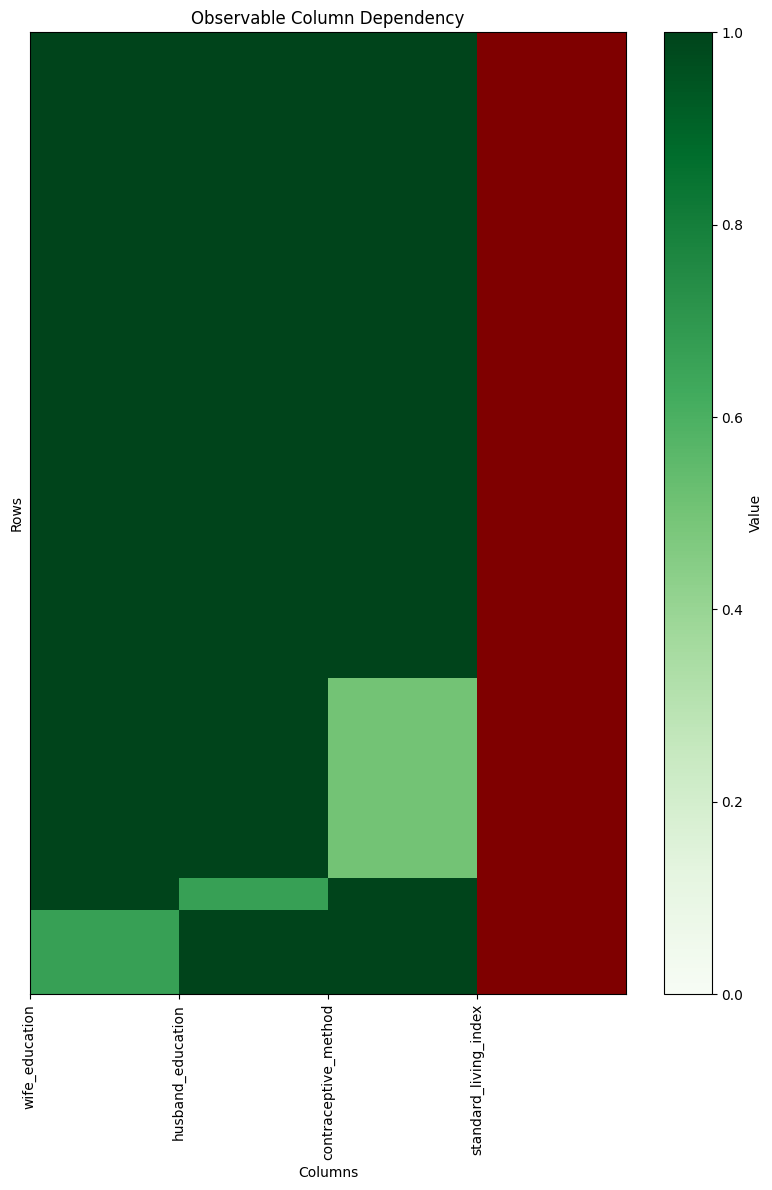

In [ ]:
from mechanism_viewer import visualize_column_dependencies

_, _ = visualize_column_dependencies(missing_df[["wife_education", "husband_education", "contraceptive_method", "standard_living_index"]], sort_by_complete=True, display_plot=True)

Clearly, the highest categorical values of the observed columns contain most of the missing values in ``standard_living_index``. The remaining missing rows tend to occur in the second highest categories of each column. Therefore, the missingness of ``standard_living_index`` is likely MAR and appears to depend on higher category values of ``wife_education``, ``husband_education``, and ``contraceptive_method``.

In other words, ``standard_living_index`` is more likely to be missing when ``wife_education`` and ``husband_education`` are in categories 3 or 4, and when ``contraceptive_method`` corresponds to short-term or long-term methods.

### 10. Detailed check of `husband_occupation`

The same tool can be used on `husband_occupation`.

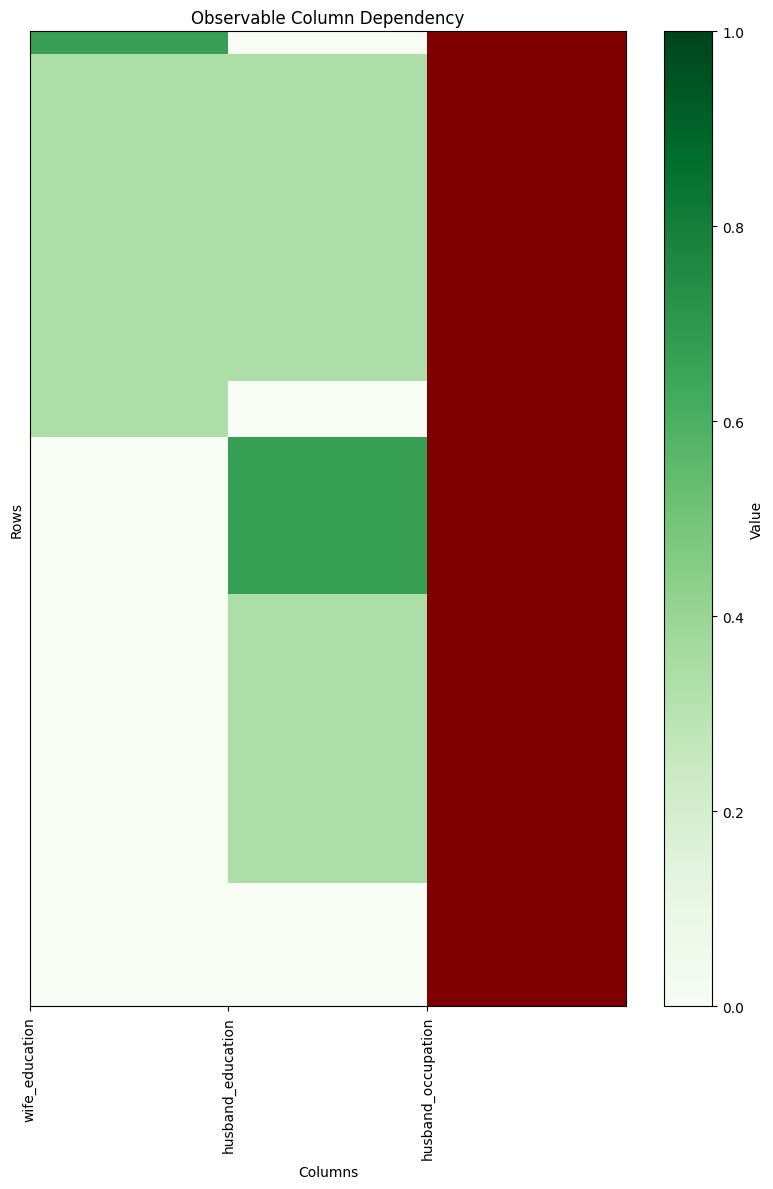

In [ ]:
from mechanism_viewer import visualize_column_dependencies

_, _ = visualize_column_dependencies(missing_df[["wife_education", "husband_education", "husband_occupation"]], sort_by_complete=True, display_plot=True)

Missing values in ``husband_occupation`` are most prevalent among lower categories of ``wife_education`` and ``husband_education``. This gives a clear MAR missing-data mechanism, but in the opposite direction from ``standard_living_index``.

### 11. Detailed check of `num_children`

During the exploration of the missingness pattern of `num_children`, there were conflicting results, mainly because `num_children` is naturally associated with `wife_age`. This section will provide sufficient evidence for the underlying missing-data mechanism of the feature.

First, some plots are shown to visualize ``num_children`` against ``wife_age``.

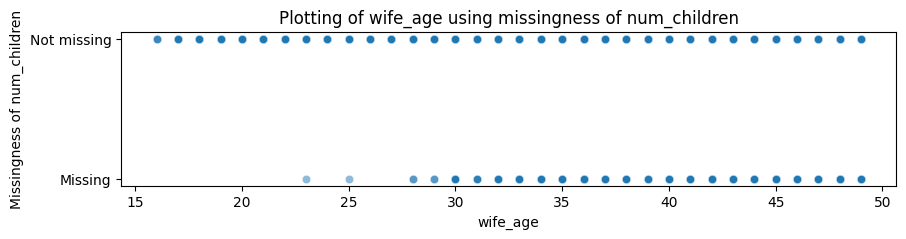

In [ ]:
from mechanism_viewer import scatter_missingness_comparison

_, _ = scatter_missingness_comparison(missing_df, column_name="wife_age", missing_col="num_children", display_plot=True)

As expected, the missing values increase in apearance with the increase of `wife_age`, although some non-missing values are still present at high levels of the observable feature.

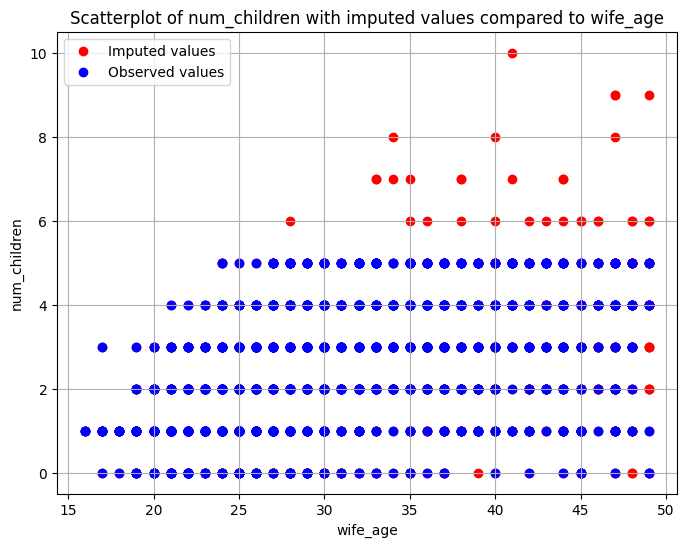

In [10]:
from mechanism_viewer import scatter_imputation_comparison, ColType

_, _ = scatter_imputation_comparison( missing_df, column_name="wife_age",
                                        missing_col="num_children",
                                        missing_col_type=ColType.DISCRETE, display_plot=True)

The scatterplot supports the previous interpretation more clearly. There are observed ``num_children`` values across most age groups, especially for low-to-medium numbers of children. However, for older ages, the imputation model predicts several missing ``num_children`` values in the higher range, especially 6+ children. Of course, previous insights showed that older ages are naturally associated with having more children. The important point here is that the imputed values increase beyond much of the observed range, suggesting that the missingness of ``num_children`` may be linked to its underlying value structure, or indirectly to ``wife_age``.

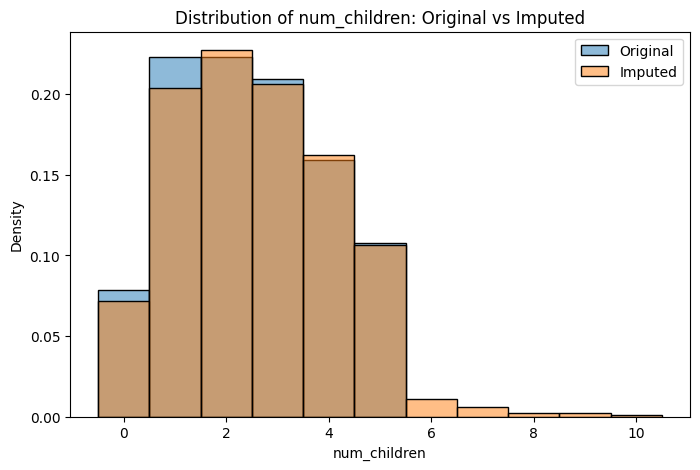

In [56]:
from mechanism_viewer import plot_imputation_distribution

_, _, imputed_df = plot_imputation_distribution(missing_df, missing_col="num_children",
                                    missing_col_type=ColType.DISCRETE, display_plot=True)

By plotting only the imputed distribution, we see that the region of 6 or more children is dominated by imputed values, as the original data contains none in this range. Interestingly, the bars for lower numbers of children decrease slightly to accommodate the imputation.

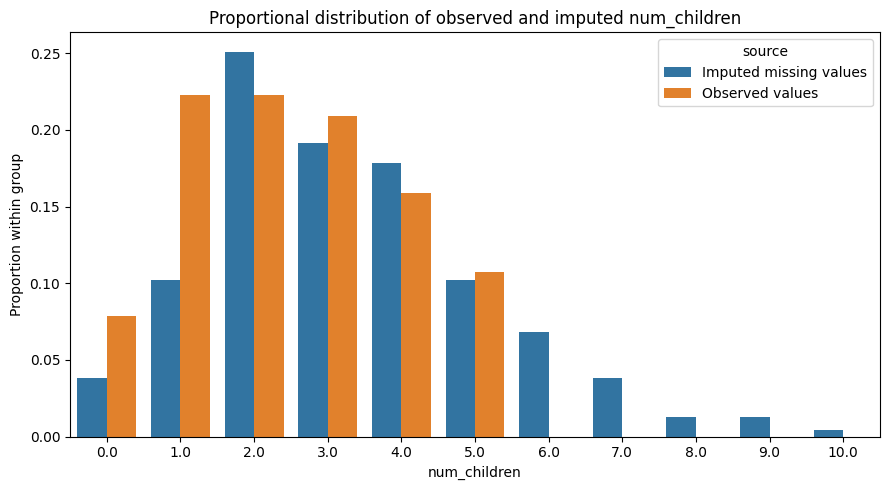

In [58]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({"num_children": pd.concat([
                            missing_df.loc[missing_df["num_children"].notna(), "num_children"],
                            imputed_df.loc[missing_df["num_children"].isna(), "num_children"]
                        ]),
                        "source": (
                            ["Observed values"] * missing_df["num_children"].notna().sum()
                            + ["Imputed missing values"] * missing_df["num_children"].isna().sum()
                        )})

dist_df = (plot_df.groupby(["source", "num_children"]).size().reset_index(name="count"))

dist_df["proportion"] = dist_df.groupby("source")["count"].transform(lambda x: x / x.sum())

plt.figure(figsize=(9, 5))
sns.barplot(data=dist_df, x="num_children", y="proportion", hue="source")

plt.title("Proportional distribution of observed and imputed num_children")
plt.xlabel("num_children")
plt.ylabel("Proportion within group")
plt.tight_layout()
plt.show()

With the imputed data in hand, a proportional distribution plot shows that the missing ``num_children`` values are not simply following the same distribution as the observed values. Instead, the imputation model predicts that some missing cases likely belong to the higher ``num_children`` range. Therefore, the missingness of `num_children` does not appear to be purely MCAR. Instead, it may reflect an MNAR or MAR pattern, with the added ambiguity that some values of ``num_children`` can be explained by observed variables such as ``wife_age``, which in turn may indirectly account for the feature's missingness.


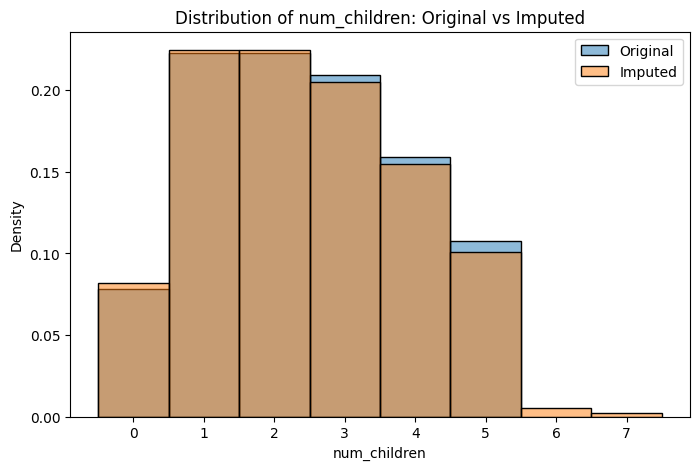

In [ ]:
_, _, imputed_df = plot_imputation_distribution(missing_df.drop(columns="wife_age"), missing_col="num_children",
                                    missing_col_type=ColType.DISCRETE, display_plot=True)

However, when the column `wife_age` is dropped from the dataset, and the imputation process is done once again for `num_children`, it is visible that the imputed dataset somewhat follows the distributed of the missing dataset, although a small region after `num_children = 6` is present. This might indicate that again `wife_age` may contribute partially to the missingness of `num_children`.

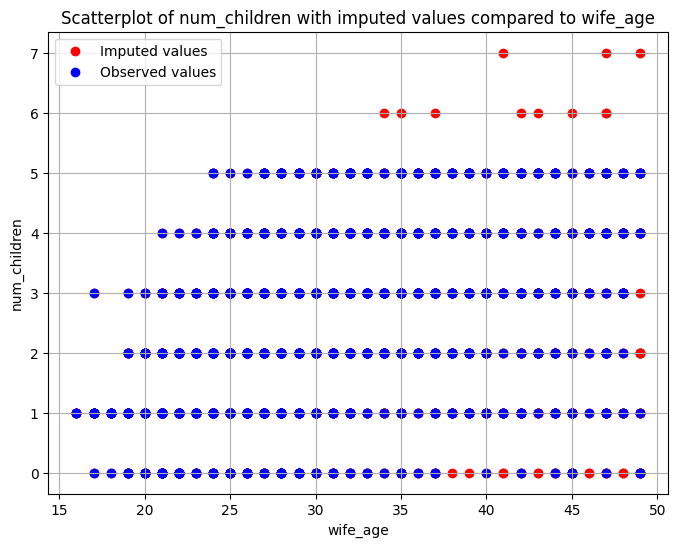

In [21]:
mask = missing_df["num_children"].isna()

imputed_x = missing_df["wife_age"]
plottable_points_before_imput = df["wife_age"].notna() & df["num_children"].notna()
plottable_points_after_imput = imputed_x.notna() & imputed_df["num_children"].notna()

plt.subplots(figsize=(8, 6))
plt.scatter(imputed_x[plottable_points_after_imput], imputed_df.loc[plottable_points_after_imput, "num_children"], color='red', label='Imputed values')   # Data points
plt.scatter(missing_df.loc[plottable_points_before_imput, "wife_age"], missing_df.loc[plottable_points_before_imput, "num_children"], color='blue', label='Observed values')
plt.title("Scatterplot of num_children with imputed values compared to wife_age")
plt.xlabel("wife_age")
plt.ylabel("num_children")
plt.grid(True)  # Just to show grid
plt.legend()

plt.show()

Some high imputed values are still present in this imputed dataset, similarly to the plot when `wife_age` was included in the imputation process. However, an increasing amount of imputed values are clear when `num_children` tends to zero. Therefore, the new imputated dataset following closely the original distribution (with missing values) of `num_children` may be due to the inclusion of imputed values in both ends of the distribution. This may reinforce the fact that the observable column `wife_age` may affect partially `num_children`.


In summary, if this missing feature was fully a MAR column, then the ABD heuristic and missingness correlation would display higher values, but that's not the current case. The missingness correlation of the feature between `wife_age` measly drops compared to the value correlation between the same observed variable. These previous plots indicate that `wife_age` may contribute partially to the explaination of the missingness pattern, but not all of it. Consequently, the missingness of ``num_children`` appears only partially attributable to observed variables, leaving open the possibility that unobserved factors or the missing values themselves contribute to the missingness process.

### 12. Quick check for `wife_working` and `media_exposure`

For `wife_working` and `media_exposure`, it is expected that a strong dependency on the observed columns should not appear. A quick test can be done to proove both features habe a MCAR missing-data mechanism.

In [60]:
columns_to_check = ["wife_working","media_exposure" ,"wife_education", "husband_education", "wife_religion", "wife_age","contraceptive_method" ]

p_value = mv.little_mcar_global(missing_df[columns_to_check])
print(mv.interpret_mcar_p_value(p_value))


Obtained p_value is 0.5048.

Interpretation: Fail to reject the null hypothesis. Data is likely MCAR


This result provides even more support that both missing features have an MCAR pattern.

### 13. Summary of missingness pattern identification

After analysing the controlled CMC missingness dataset, the main conclusions are:

- `wife_working` and `media_exposure` behave like MCAR columns. Their missingness does not appear meaningfully associated with the observed demographic variables.

- `standard_living_index` behaves like MAR. Its missingness is concentrated in rows with higher `wife_education`, higher `husband_education`, and higher `contraceptive_method` code.

- `husband_occupation` also behaves like MAR, but in the opposite direction. Its missingness is concentrated in rows with lower `wife_education` and lower `husband_education`.

- `num_children` column behaviour is somewhat inconclusive. Although there are evidences exhibiting non-MAR and non-MCAR missing patterns, the association of the observed feature `wife_age` may indicate that the column has some MAR traces. And since it is hard to find evidences for MNAR mechanism, the result is better described as ambiguous between MAR and MNAR, rather than as a clear MNAR case. The best approach is to use domain knowledge to arrive at conclusions.

### 14. Final conclusion

Overall, the notebook shows that `mechanism_viewer` can recover the main injected patterns in this dataset. But more importantly, the notebook exposes the practical ambiguity of detecting MNAR when the missing variable is correlated with the observed features. In these cases, MNAR and MAR can be difficult to separate using plots and model accuracy alone.